In [2]:
import pandas as pd

df = pd.read_excel(r"C:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\cleaned_data.xlsx")

In [3]:
df

,Title,Body,Tags,Id,Score,ViewCount,FavoriteCount,AnswerCount,Body_no_html,cleaned_Body,cleaned_Title,title_length,body_length
0,Paging a collection with LINQ,<p>How do you page through a collection in LIN...,<linq><.net-3.5>,66,89,6427,NaN,4,How do you page through a collection in LINQ g...,page collection linq give startindex count,page collection linq,29,91
1,How do I add existing comments to RDoc in Ruby?,<p>I want to format my existing comments as 'R...,<ruby><rdoc>,72,48,2232,NaN,2,I want to format my existing comments as 'RDoc...,want format exist comment rdoc comment view ri...,add exist comment rdoc ruby,47,154
2,Getting Subclipse in Aptana to work with the n...,<p>The version of <strong>Subclipse (1.2.4)</s...,<eclipse><svn><aptana><subclipse>,79,50,11502,NaN,4,The version of Subclipse (1.2.4) currently ava...,version subclipse 1.2.4 currently available ap...,get subclipse aptana work new release subversion,73,981
3,SQLStatement.execute() - multiple queries in o...,<p>I've written a database generation script i...,<apache-flex><actionscript-3><air>,80,54,6774,NaN,3,I've written a database generation script in S...,write database generation script sql want exec...,sqlstatement.execute multiple query statement,58,1725
4,Flat file databases,<p>What are the best practices around creating...,<php><sql><database><flat-file>,85,133,70693,NaN,11,What are the best practices around creating fl...,good practice create flat file database struct...,flat file database,19,392
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Let the user specify in which account a servic...,<p>I've got a windows service that should run ...,<wix>,9568169,7,6766,NaN,1,I've got a windows service that should run und...,get window service run domain account specify ...,let user specify account service run,52,387
96,"how to handle a click event only on, the eleme...",<p>I need to make a show navigation click even...,<jquery>,9568171,0,69,NaN,1,I need to make a show navigation click event t...,need navigation click event ipad app mean clic...,handle click event element hold event,88,686
97,Cannot find reason for java.io.OptionalDataExc...,<p>I'm trying to serialize an object and store...,<java><android><serialization><deserialization>,9568177,1,4303,NaN,2,I'm trying to serialize an object and store it...,try serialize object store sd card essentially...,find reason java.io optionaldataexception code,63,3711
98,Simple J2ME SMS code debugging,<p>I'm trying to develop J2ME SMS applications...,<debugging><java-me><midp><netbeans-7><wma>,9568181,1,1031,NaN,1,I'm trying to develop J2ME SMS applications (o...,try develop j2me sms application symbian impor...,simple j2me sms code debugging,30,1219


In [4]:
df_body_title_tags = df[["cleaned_Body", "cleaned_Title", "Tags"]]

In [5]:
df_body_title_tags

,cleaned_Body,cleaned_Title,Tags
0,page collection linq give startindex count,page collection linq,<linq><.net-3.5>
1,want format exist comment rdoc comment view ri...,add exist comment rdoc ruby,<ruby><rdoc>
2,version subclipse 1.2.4 currently available ap...,get subclipse aptana work new release subversion,<eclipse><svn><aptana><subclipse>
3,write database generation script sql want exec...,sqlstatement.execute multiple query statement,<apache-flex><actionscript-3><air>
4,good practice create flat file database struct...,flat file database,<php><sql><database><flat-file>
...,...,...,...
95,get window service run domain account specify ...,let user specify account service run,<wix>
96,need navigation click event ipad app mean clic...,handle click event element hold event,<jquery>
97,try serialize object store sd card essentially...,find reason java.io optionaldataexception code,<java><android><serialization><deserialization>
98,try develop j2me sms application symbian impor...,simple j2me sms code debugging,<debugging><java-me><midp><netbeans-7><wma>


In [6]:
from sklearn.feature_extraction.text import CountVectorizer

In [7]:
def remove_html_tags(text):
    """Remove HTML tags from a string."""
    text = text.str.replace(r"><", ",", regex=True)
    text = text.str.replace(r">|<", "", regex=True)
    return (text)

df_body_title_tags["Tags"] = remove_html_tags(df_body_title_tags["Tags"])

C:\Users\solay\AppData\Local\Temp\ipykernel_35776\188697831.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_body_title_tags["Tags"] = remove_html_tags(df_body_title_tags["Tags"])


In [8]:
df_body_title_tags

,cleaned_Body,cleaned_Title,Tags
0,page collection linq give startindex count,page collection linq,"linq,.net-3.5"
1,want format exist comment rdoc comment view ri...,add exist comment rdoc ruby,"ruby,rdoc"
2,version subclipse 1.2.4 currently available ap...,get subclipse aptana work new release subversion,"eclipse,svn,aptana,subclipse"
3,write database generation script sql want exec...,sqlstatement.execute multiple query statement,"apache-flex,actionscript-3,air"
4,good practice create flat file database struct...,flat file database,"php,sql,database,flat-file"
...,...,...,...
95,get window service run domain account specify ...,let user specify account service run,wix
96,need navigation click event ipad app mean clic...,handle click event element hold event,jquery
97,try serialize object store sd card essentially...,find reason java.io optionaldataexception code,"java,android,serialization,deserialization"
98,try develop j2me sms application symbian impor...,simple j2me sms code debugging,"debugging,java-me,midp,netbeans-7,wma"


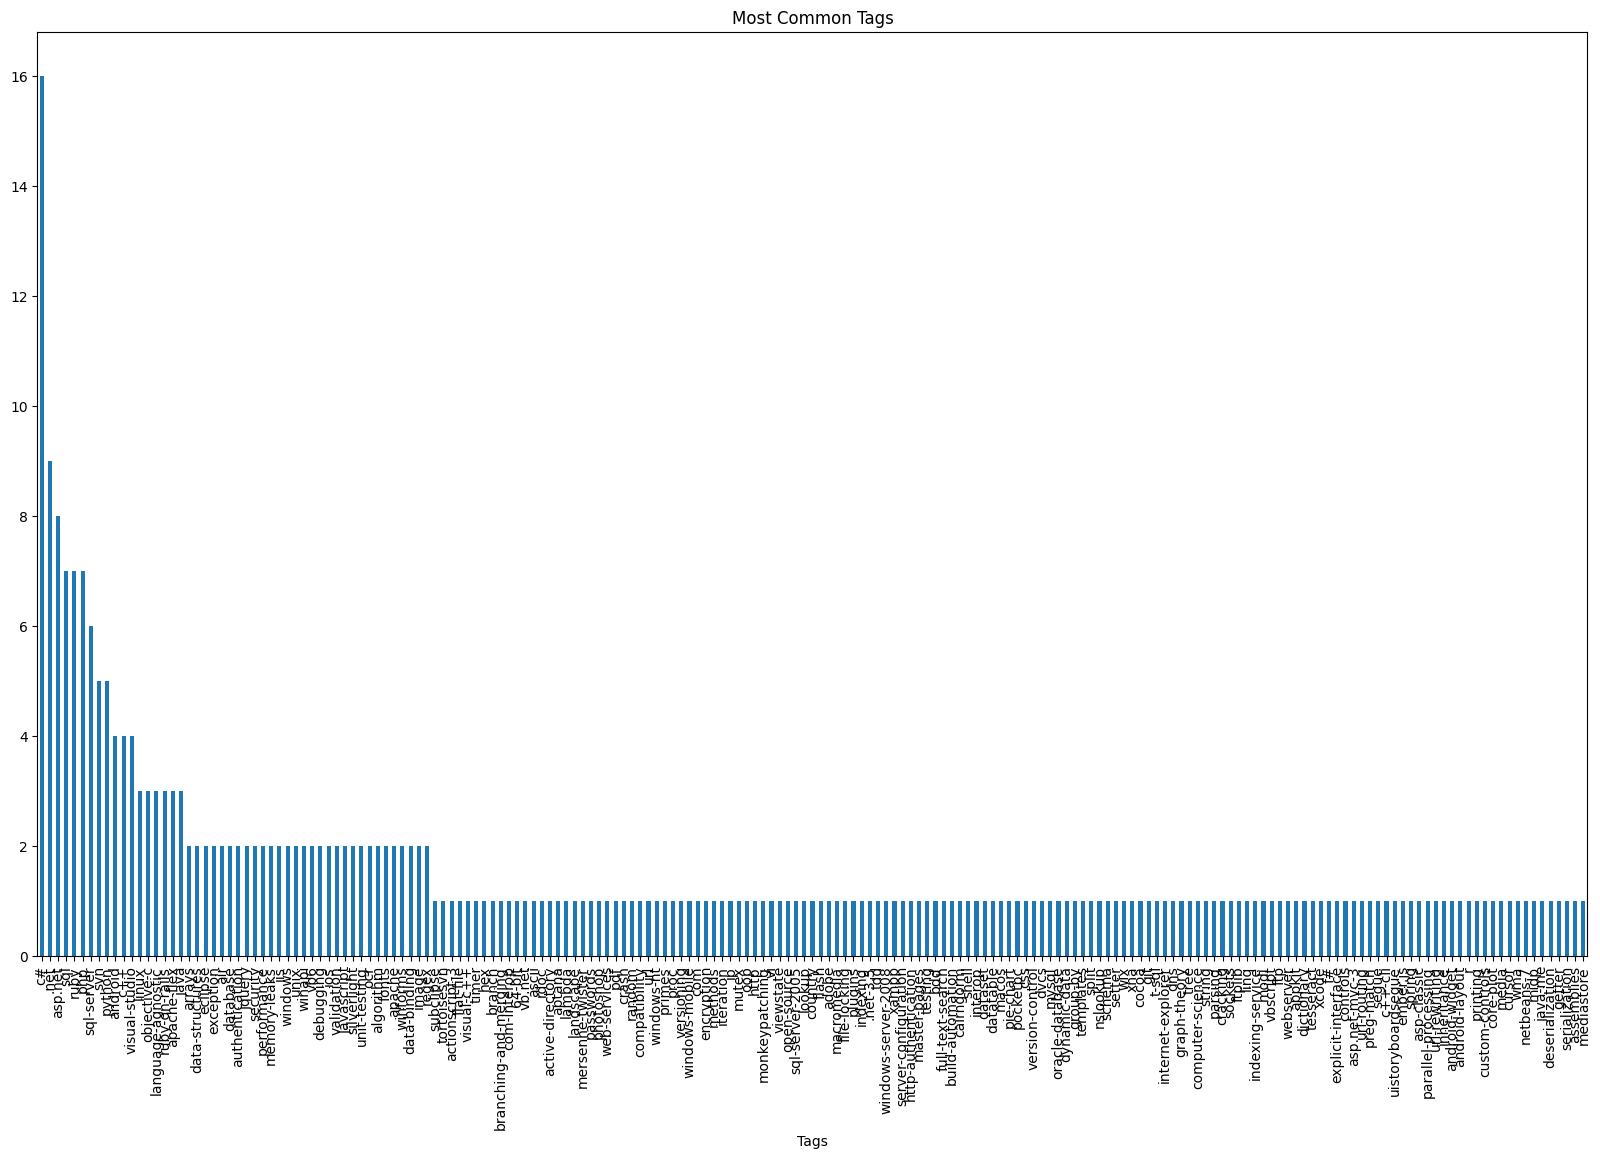

In [9]:
import matplotlib.pyplot as plt
all_tags = df_body_title_tags["Tags"].str.split(",").explode().value_counts()
all_tags.sort_values(ascending=False).plot(kind='bar', figsize=(20, 12), title="Most Common Tags")
plt.show()

In [10]:
all_tags = all_tags[all_tags >= 2]

In [11]:
Y = df_body_title_tags["Tags"].str.get_dummies(sep=",")

In [12]:
Y = Y[all_tags.index]

In [13]:
df_final = pd.concat([df_body_title_tags["cleaned_Body"], Y], axis=1)

In [14]:
from sklearn.model_selection import train_test_split

# Séparation en train/test (80% train, 20% test)
body_train, body_test, Y_train, Y_test = train_test_split(df_body_title_tags["cleaned_Body"], Y, test_size=0.2, random_state=42)

In [15]:
body_train

55    add rule visual studio 2005 validate property ...
88    work application business client currently des...
26    fast secure way encrypt password php preferabl...
42    set dedicated sql server 2005 box windows serv...
69    dad call today say people go website get 168 v...
                            ...                        
60    sql server split string access item x string h...
71    common problem solve data structure good recom...
14    photoshop javascript api find font give psd gi...
92    like add font picker app xcode interface build...
51    currently use datatable result database use co...
Name: cleaned_Body, Length: 80, dtype: object

In [16]:
Y_train

,c#,.net,asp.net,sql,ruby,php,sql-server,svn,python,android,...,air,database,arrays,winapi,jquery,authentication,performance,memory-leaks,iis,windows
55,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
88,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
26,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
42,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,0,0,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
71,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
92,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
#CountVectorizer fit transform sur body train et transform sur body Y_test

#entrainer un model de regression logistique en utilisant la fonction multioutputclassifier de sklearn
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(body_train)
X_test = vectorizer.transform(body_test)
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression

# Remove columns with only one class in Y_train
valid_cols = [col for col in Y_train.columns if len(Y_train[col].unique()) > 1]
Y_train_valid = Y_train[valid_cols]
Y_test_valid = Y_test[valid_cols]

classifier = MultiOutputClassifier(LogisticRegression(max_iter=1000))
classifier.fit(X_train, Y_train_valid)
# Prédiction sur le test set
Y_pred = classifier.predict(X_test)
from sklearn.metrics import accuracy_score, f1_score
# Calcul de l'accuracy et du f1 score
accuracy = accuracy_score(Y_test_valid, Y_pred)
f1 = f1_score(Y_test_valid, Y_pred, average='weighted')
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
# Sauvegarde du modèle et du vectorizer

Accuracy: 0.2000
F1 Score: 0.0536


c:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [21]:
from sklearn.multioutput import ClassifierChain

cc = ClassifierChain(LogisticRegression(max_iter=1000))
cc.fit(X_train, Y_train_valid)

Y_pred_cc = cc.predict(X_test)
accuracy_cc = accuracy_score(Y_test_valid, Y_pred_cc)
f1_cc = f1_score(Y_test_valid, Y_pred_cc, average='weighted')
print(f"Classifier Chain Accuracy: {accuracy_cc:.4f}")
print(f"Classifier Chain F1 Score: {f1_cc:.4f}")

Classifier Chain Accuracy: 0.2000
Classifier Chain F1 Score: 0.0536


c:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
regarder comment mlflow fonctionne

SyntaxError: invalid syntax (1341991082.py, line 1)

In [19]:
Y_train_valid

,c#,.net,asp.net,sql,ruby,php,sql-server,svn,python,android,...,air,database,arrays,winapi,jquery,authentication,performance,memory-leaks,iis,windows
55,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
88,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
26,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
42,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,0,0,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
71,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
92,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
Y_train_mlb = mlb.fit_transform(Y_train_valid.values)
Y_test_mlb = mlb.transform(Y_test_valid.values)

ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000))
ovr.fit(X_train, Y_train_mlb)
Y_pred_mlb = ovr.predict(X_test)
accuracy_mlb = accuracy_score(Y_test_mlb, Y_pred_mlb)
f1_mlb = f1_score(Y_test_mlb, Y_pred_mlb, average='weighted')
print(f"MLB Accuracy: {accuracy_mlb:.4f}")
print(f"MLB F1 Score: {f1_mlb:.4f}")


MLB Accuracy: 0.8000
MLB F1 Score: 0.9506


c:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label 0 is present in all training examples.
  warnings.warn(


## Création du modèle Word2Vec

In [33]:
import gensim
from tensorflow.keras.preprocessing.text import Tokenizer

In [30]:
w2v_size=300
w2v_window=5
w2v_min_count=1
w2v_epochs=100
maxlen = 24 # adapt to length of sentences
sentences = df_final['cleaned_Body'].to_list()
sentences = [gensim.utils.simple_preprocess(text) for text in sentences]

In [31]:
# Création et entraînement du modèle Word2Vec

print("Build & train Word2Vec model ...")
w2v_model = gensim.models.Word2Vec(min_count=w2v_min_count, window=w2v_window,
                                                vector_size=w2v_size,
                                                seed=42,
                                                workers=1)
#                                                workers=multiprocessing.cpu_count())
w2v_model.build_vocab(sentences)
w2v_model.train(sentences, total_examples=w2v_model.corpus_count, epochs=w2v_epochs)
model_vectors = w2v_model.wv
w2v_words = model_vectors.index_to_key
print("Vocabulary size: %i" % len(w2v_words))
print("Word2Vec trained")

Build & train Word2Vec model ...
Vocabulary size: 1630
Word2Vec trained


In [36]:
# Préparation des sentences (tokenization)
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("Fit Tokenizer ...")
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)
x_sentences = pad_sequences(tokenizer.texts_to_sequences(sentences),
                                                     maxlen=maxlen,
                                                     padding='post') 
                                                   
num_words = len(tokenizer.word_index) + 1
print("Number of unique words: %i" % num_words)

Fit Tokenizer ...
Number of unique words: 1631


## Création de la matrice d'embedding

In [38]:
# Création de la matrice d'embedding
import numpy as np

print("Create Embedding matrix ...")
w2v_size = 300
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1
embedding_matrix = np.zeros((vocab_size, w2v_size))
i=0
j=0
    
for word, idx in word_index.items():
    i +=1
    if word in w2v_words:
        j +=1
        embedding_vector = model_vectors[word]
        if embedding_vector is not None:
            embedding_matrix[idx] = model_vectors[word]
            
word_rate = np.round(j/i,4)
print("Word embedding rate : ", word_rate)
print("Embedding matrix: %s" % str(embedding_matrix.shape))

Create Embedding matrix ...
Word embedding rate :  1.0
Embedding matrix: (1631, 300)


## Création du modèle d'embedding

In [41]:
# Création du modèle
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

input=Input(shape=(len(x_sentences),maxlen),dtype='float64')
word_input=Input(shape=(maxlen,),dtype='float64')  
word_embedding=Embedding(input_dim=vocab_size,
                         output_dim=w2v_size,
                         weights = [embedding_matrix],
                         input_length=maxlen)(word_input)
word_vec=GlobalAveragePooling1D()(word_embedding)  
embed_model = Model([word_input],word_vec)

embed_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 24, 300)        │       489,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 300)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 489,300 (1.87 MB)

 Trainable params: 489,300 (1.87 MB)

 Non-trainable params: 0 (0.00 B)

## Exécution du modèle

In [45]:
embeddings = embed_model.predict(x_sentences)
embeddings.shape

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


(100, 300)

In [44]:
mettre dans une regression logistique

SyntaxError: invalid syntax (2051184138.py, line 1)

In [51]:
# Séparation en train/test (80% train, 20% test)
emb_train, emb_test, Y_train, Y_test = train_test_split(embeddings, Y, test_size=0.2, random_state=42)

In [ ]:
faire une fonction plutot que de le rappeler

In [ ]:
#CountVectorizer fit transform sur body train et transform sur body Y_test

#entrainer un model de regression logistique en utilisant la fonction multioutputclassifier de sklearn
# Remove columns with only one class in Y_train
valid_cols = [col for col in Y_train.columns if len(Y_train[col].unique()) > 1]
Y_train_valid = Y_train[valid_cols]
Y_test_valid = Y_test[valid_cols]

classifier = MultiOutputClassifier(LogisticRegression(max_iter=1000))
classifier.fit(emb_train, Y_train_valid)
# Prédiction sur le test set
Y_pred = classifier.predict(emb_test)
from sklearn.metrics import accuracy_score, f1_score
# Calcul de l'accuracy et du f1 score
accuracy = accuracy_score(Y_test_valid, Y_pred)
f1 = f1_score(Y_test_valid, Y_pred, average='weighted')
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
# Sauvegarde du modèle et du vectorizer

Accuracy: 0.2000
F1 Score: 0.0000


c:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [55]:
cc = ClassifierChain(LogisticRegression(max_iter=1000))
cc.fit(emb_train, Y_train_valid)

Y_pred_cc = cc.predict(emb_test)
accuracy_cc = accuracy_score(Y_test_valid, Y_pred_cc)
f1_cc = f1_score(Y_test_valid, Y_pred_cc, average='weighted')
print(f"Classifier Chain Accuracy: {accuracy_cc:.4f}")
print(f"Classifier Chain F1 Score: {f1_cc:.4f}")

Classifier Chain Accuracy: 0.2000
Classifier Chain F1 Score: 0.0000


c:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [56]:
mlb = MultiLabelBinarizer()
Y_train_mlb = mlb.fit_transform(Y_train_valid.values)
Y_test_mlb = mlb.transform(Y_test_valid.values)

ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000))
ovr.fit(emb_train, Y_train_mlb)
Y_pred_mlb = ovr.predict(emb_test)
accuracy_mlb = accuracy_score(Y_test_mlb, Y_pred_mlb)
f1_mlb = f1_score(Y_test_mlb, Y_pred_mlb, average='weighted')
print(f"MLB Accuracy: {accuracy_mlb:.4f}")
print(f"MLB F1 Score: {f1_mlb:.4f}")

MLB Accuracy: 0.8000
MLB F1 Score: 0.9506


c:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label 0 is present in all training examples.
  warnings.warn(


#BERT

In [59]:
import tensorflow as tf
# import tensorflow_hub as hub
import tensorflow.keras
from tensorflow.keras import backend as K

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import metrics as kmetrics
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

# Bert
import os
import transformers
from transformers import *

os.environ["TF_KERAS"]='1'

In [60]:
print(tf.__version__)
print(tensorflow.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

2.19.0
2.19.0
Num GPUs Available:  0
False


# FONCTIONS COMMUNES

In [62]:
import time
# Fonction de préparation des sentences
def bert_inp_fct(sentences, bert_tokenizer, max_length) :
    input_ids=[]
    token_type_ids = []
    attention_mask=[]
    bert_inp_tot = []

    for sent in sentences:
        bert_inp = bert_tokenizer.encode_plus(sent,
                                              add_special_tokens = True,
                                              max_length = max_length,
                                              padding='max_length',
                                              return_attention_mask = True, 
                                              return_token_type_ids=True,
                                              truncation=True,
                                              return_tensors="tf")
    
        input_ids.append(bert_inp['input_ids'][0])
        token_type_ids.append(bert_inp['token_type_ids'][0])
        attention_mask.append(bert_inp['attention_mask'][0])
        bert_inp_tot.append((bert_inp['input_ids'][0], 
                             bert_inp['token_type_ids'][0], 
                             bert_inp['attention_mask'][0]))

    input_ids = np.asarray(input_ids)
    token_type_ids = np.asarray(token_type_ids)
    attention_mask = np.array(attention_mask)
    
    return input_ids, token_type_ids, attention_mask, bert_inp_tot
    

# Fonction de création des features
def feature_BERT_fct(model, model_type, sentences, max_length, b_size, mode='HF') :
    batch_size = b_size
    batch_size_pred = b_size
    bert_tokenizer = AutoTokenizer.from_pretrained(model_type)
    time1 = time.time()

    for step in range(len(sentences)//batch_size) :
        idx = step*batch_size
        input_ids, token_type_ids, attention_mask, bert_inp_tot = bert_inp_fct(sentences[idx:idx+batch_size], 
                                                                      bert_tokenizer, max_length)
        
        if mode=='HF' :    # Bert HuggingFace
            outputs = model.predict([input_ids, attention_mask, token_type_ids], batch_size=batch_size_pred)
            last_hidden_states = outputs.last_hidden_state

        if mode=='TFhub' : # Bert Tensorflow Hub
            text_preprocessed = {"input_word_ids" : input_ids, 
                                 "input_mask" : attention_mask, 
                                 "input_type_ids" : token_type_ids}
            outputs = model(text_preprocessed)
            last_hidden_states = outputs['sequence_output']
             
        if step ==0 :
            last_hidden_states_tot = last_hidden_states
            last_hidden_states_tot_0 = last_hidden_states
        else :
            last_hidden_states_tot = np.concatenate((last_hidden_states_tot,last_hidden_states))
    
    features_bert = np.array(last_hidden_states_tot).mean(axis=1)
    
    time2 = np.round(time.time() - time1,0)
    print("temps traitement : ", time2)
     
    return features_bert, last_hidden_states_tot

## BERT HuggingFace

In [64]:
max_length = 64
batch_size = 10
model_type = 'bert-base-uncased'
model = TFAutoModel.from_pretrained(model_type)
sentences = df_final['cleaned_Body'].to_list()

loading configuration file config.json from cache at C:\Users\solay\.cache\huggingface\hub\models--bert-base-uncased\snapshots\86b5e0934494bd15c9632b12f734a8a67f723594\config.json
Model config BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.53.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

loading weights file model.safetensors from cache at C:\Users\solay\.cache\huggingface\hub\models--bert-base-uncased\snapshots\86b5e0934494bd15c9632b12f734a8a67f723594\model.safetensors
Loaded 109,48

In [66]:
# Création des features

features_bert, last_hidden_states_tot = feature_BERT_fct(model, model_type, sentences, 
                                                         max_length, batch_size, mode='HF')

loading configuration file config.json from cache at C:\Users\solay\.cache\huggingface\hub\models--bert-base-uncased\snapshots\86b5e0934494bd15c9632b12f734a8a67f723594\config.json
Model config BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.53.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

loading file vocab.txt from cache at C:\Users\solay\.cache\huggingface\hub\models--bert-base-uncased\snapshots\86b5e0934494bd15c9632b12f734a8a67f723594\vocab.txt
loading file tokenizer.json from cach

1/1 [==============================] - 1s 1s/step
temps traitement :  25.0


In [67]:
# Séparation en train/test (80% train, 20% test)
emb_train, emb_test, Y_train, Y_test = train_test_split(features_bert, Y, test_size=0.2, random_state=42)

In [ ]:
#CountVectorizer fit transform sur body train et transform sur body Y_test

#entrainer un model de regression logistique en utilisant la fonction multioutputclassifier de sklearn
# Remove columns with only one class in Y_train
valid_cols = [col for col in Y_train.columns if len(Y_train[col].unique()) > 1]
Y_train_valid = Y_train[valid_cols]
Y_test_valid = Y_test[valid_cols]

classifier = MultiOutputClassifier(LogisticRegression(max_iter=1000))
classifier.fit(emb_train, Y_train_valid)
# Prédiction sur le test set
Y_pred = classifier.predict(emb_test)
from sklearn.metrics import accuracy_score, f1_score
# Calcul de l'accuracy et du f1 score
accuracy = accuracy_score(Y_test_valid, Y_pred)
f1 = f1_score(Y_test_valid, Y_pred, average='weighted')
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
# Sauvegarde du modèle et du vectorizer
cc = ClassifierChain(LogisticRegression(max_iter=1000))
cc.fit(emb_train, Y_train_valid)

Y_pred_cc = cc.predict(emb_test)
accuracy_cc = accuracy_score(Y_test_valid, Y_pred_cc)
f1_cc = f1_score(Y_test_valid, Y_pred_cc, average='weighted')
print(f"Classifier Chain Accuracy: {accuracy_cc:.4f}")
print(f"Classifier Chain F1 Score: {f1_cc:.4f}")
mlb = MultiLabelBinarizer()
Y_train_mlb = mlb.fit_transform(Y_train_valid.values)
Y_test_mlb = mlb.transform(Y_test_valid.values)

ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000))
ovr.fit(emb_train, Y_train_mlb)
Y_pred_mlb = ovr.predict(emb_test)
accuracy_mlb = accuracy_score(Y_test_mlb, Y_pred_mlb)
f1_mlb = f1_score(Y_test_mlb, Y_pred_mlb, average='weighted')
print(f"MLB Accuracy: {accuracy_mlb:.4f}")
print(f"MLB F1 Score: {f1_mlb:.4f}")


c:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.2000
F1 Score: 0.0000


c:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label 0 is present in all training examples.
  warnings.warn(


Classifier Chain Accuracy: 0.2000
Classifier Chain F1 Score: 0.0000
MLB Accuracy: 0.8000
MLB F1 Score: 0.9506


In [70]:
# USE (Universal Sentence Encoder)
import tensorflow_hub as hub
import numpy as np

# Chargement du modèle USE
print("Chargement du modèle Universal Sentence Encoder...")
use_model = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")
print("Modèle USE chargé avec succès")

c:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\.venv\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Chargement du modèle Universal Sentence Encoder...



Modèle USE chargé avec succès


In [71]:
# Fonction pour créer les embeddings avec USE
def create_use_embeddings(sentences, model, batch_size=32):
    """
    Créer les embeddings USE pour une liste de phrases
    """
    embeddings = []
    total_batches = len(sentences) // batch_size + (1 if len(sentences) % batch_size != 0 else 0)
    
    print(f"Traitement de {len(sentences)} phrases en {total_batches} batches...")
    
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i + batch_size]
        batch_embeddings = model(batch)
        embeddings.append(batch_embeddings.numpy())
        
        if (i // batch_size + 1) % 10 == 0:
            print(f"Batch {i // batch_size + 1}/{total_batches} traité")
    
    # Concaténer tous les embeddings
    all_embeddings = np.vstack(embeddings)
    print(f"Embeddings créés avec succès. Shape: {all_embeddings.shape}")
    
    return all_embeddings

In [72]:
# Création des embeddings USE
sentences = df_final['cleaned_Body'].to_list()
use_embeddings = create_use_embeddings(sentences, use_model, batch_size=32)

Traitement de 100 phrases en 4 batches...
Embeddings créés avec succès. Shape: (100, 512)


In [73]:
# Séparation en train/test (80% train, 20% test) pour USE
use_train, use_test, Y_train, Y_test = train_test_split(use_embeddings, Y, test_size=0.2, random_state=42)

print(f"USE Train shape: {use_train.shape}")
print(f"USE Test shape: {use_test.shape}")
print(f"Y Train shape: {Y_train.shape}")
print(f"Y Test shape: {Y_test.shape}")

USE Train shape: (80, 512)
USE Test shape: (20, 512)
Y Train shape: (80, 48)
Y Test shape: (20, 48)


In [74]:
# Modèles de classification avec USE
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Remove columns with only one class in Y_train
valid_cols = [col for col in Y_train.columns if len(Y_train[col].unique()) > 1]
Y_train_valid = Y_train[valid_cols]
Y_test_valid = Y_test[valid_cols]

print(f"Nombre de labels valides: {len(valid_cols)}")
print("=" * 50)

# 1. MultiOutputClassifier avec USE
print("1. MultiOutputClassifier avec USE")
classifier_use = MultiOutputClassifier(LogisticRegression(max_iter=1000))
classifier_use.fit(use_train, Y_train_valid)

Y_pred_use = classifier_use.predict(use_test)
accuracy_use = accuracy_score(Y_test_valid, Y_pred_use)
f1_use = f1_score(Y_test_valid, Y_pred_use, average='weighted')
print(f"USE MultiOutput Accuracy: {accuracy_use:.4f}")
print(f"USE MultiOutput F1 Score: {f1_use:.4f}")
print()

# 2. ClassifierChain avec USE
print("2. ClassifierChain avec USE")
cc_use = ClassifierChain(LogisticRegression(max_iter=1000))
cc_use.fit(use_train, Y_train_valid)

Y_pred_cc_use = cc_use.predict(use_test)
accuracy_cc_use = accuracy_score(Y_test_valid, Y_pred_cc_use)
f1_cc_use = f1_score(Y_test_valid, Y_pred_cc_use, average='weighted')
print(f"USE Classifier Chain Accuracy: {accuracy_cc_use:.4f}")
print(f"USE Classifier Chain F1 Score: {f1_cc_use:.4f}")
print()

# 3. OneVsRestClassifier avec MultiLabelBinarizer et USE
print("3. OneVsRestClassifier avec MultiLabelBinarizer et USE")
mlb_use = MultiLabelBinarizer()
Y_train_mlb_use = mlb_use.fit_transform(Y_train_valid.values)
Y_test_mlb_use = mlb_use.transform(Y_test_valid.values)

ovr_use = OneVsRestClassifier(LogisticRegression(max_iter=1000))
ovr_use.fit(use_train, Y_train_mlb_use)
Y_pred_mlb_use = ovr_use.predict(use_test)
accuracy_mlb_use = accuracy_score(Y_test_mlb_use, Y_pred_mlb_use)
f1_mlb_use = f1_score(Y_test_mlb_use, Y_pred_mlb_use, average='weighted')
print(f"USE MLB Accuracy: {accuracy_mlb_use:.4f}")
print(f"USE MLB F1 Score: {f1_mlb_use:.4f}")

Nombre de labels valides: 47
1. MultiOutputClassifier avec USE


c:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


USE MultiOutput Accuracy: 0.2000
USE MultiOutput F1 Score: 0.0000

2. ClassifierChain avec USE
USE Classifier Chain Accuracy: 0.2000
USE Classifier Chain F1 Score: 0.0000

3. OneVsRestClassifier avec MultiLabelBinarizer et USE
USE MLB Accuracy: 0.8000
USE MLB F1 Score: 0.9506


c:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label 0 is present in all training examples.
  warnings.warn(


In [75]:
# Comparaison des résultats (optionnel)
import pandas as pd

results_comparison = pd.DataFrame({
    'Model': ['CountVectorizer', 'Word2Vec', 'BERT', 'USE'],
    'Method': ['MultiOutput', 'MultiOutput', 'MultiOutput', 'MultiOutput'],
    'Accuracy': [accuracy, 'accuracy_w2v', accuracy, accuracy_use],  # Remplacez par les vraies valeurs
    'F1_Score': [f1, 'f1_w2v', f1, f1_use]  # Remplacez par les vraies valeurs
})

print("Comparaison des performances:")
print(results_comparison)

Comparaison des performances:
             Model       Method      Accuracy F1_Score
0  CountVectorizer  MultiOutput           0.2      0.0
1         Word2Vec  MultiOutput  accuracy_w2v   f1_w2v
2             BERT  MultiOutput           0.2      0.0
3              USE  MultiOutput           0.2      0.0


In [76]:
faire la même chose (prédiction) avec USE au lieu de BERT
10 h 56
Créer un compte heroku et lier son compte github student
10 h 57
Faire une api en .py qui prend une phrase et retroune un pré"diction
10 h 57
Pour l'api, utiliser le modèle countvectorizer  + regression logistique

SyntaxError: unterminated string literal (detected at line 5) (2249640620.py, line 5)